<a href="https://colab.research.google.com/github/Raffy0-1/CodeAlpha-handwritten_character_recognition/blob/main/handwritten_character_recognition.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Handwritten Character Recognition

This notebook walks through building a complete handwritten character recognition system from scratch.
We will go from raw pixel data to a trained CNN, visualize what the model actually learns using Grad-CAM,
scale up from digits to full characters with EMNIST, and finally understand how sequence models like CRNN
extend this to full word recognition.


---
## Section 1: Environment Setup and Google Drive Integration

Before anything else, we mount Google Drive. The reason is simple: Colab's free tier gives you a GPU
for a limited session. When the session ends, everything in Colab's local storage is wiped.

By saving model weights, training history, and datasets directly to Drive, we can resume from exactly
where we left off without retraining. This is the same pattern used in real ML workflows with cloud storage.

We will also define all folder paths here in one place. That way, if you ever change your Drive folder
structure, you only update it in one spot.

In [1]:
from google.colab import drive
import os

# Mount Google Drive at /content/drive
# When you run this, Colab will ask you to authorize access via your Google account
drive.mount('/content/drive')

# Define the root project folder on your Drive
# All models, histories, and datasets will be saved under this path
PROJECT_ROOT = '/content/drive/MyDrive/handwriting_recognition'

# Sub-folders for organization
MNIST_MODEL_PATH    = os.path.join(PROJECT_ROOT, 'models', 'mnist_cnn.h5')
EMNIST_MODEL_PATH   = os.path.join(PROJECT_ROOT, 'models', 'emnist_cnn.h5')
HISTORY_DIR         = os.path.join(PROJECT_ROOT, 'history')
DATASET_DIR         = os.path.join(PROJECT_ROOT, 'datasets')

# Create all directories if they do not already exist
# exist_ok=True means no error is thrown if the folder is already there
for folder in [os.path.join(PROJECT_ROOT, 'models'), HISTORY_DIR, DATASET_DIR]:
    os.makedirs(folder, exist_ok=True)

print('Drive mounted and project folders ready.')
print(f'Project root: {PROJECT_ROOT}')

Mounted at /content/drive
Drive mounted and project folders ready.
Project root: /content/drive/MyDrive/handwriting_recognition


### Install and Import Dependencies

We use TensorFlow as the main deep learning framework. It includes Keras as its high-level API,
which lets us build and train neural networks in a clean, readable way.

tensorflow-datasets gives us easy access to EMNIST without manual downloading.
opencv-python (cv2) is used for image processing utilities like resizing and color conversion.
matplotlib and seaborn are for all our visualizations.

In [5]:
import sys

# Install specific versions pinned for Colab compatibility
# These versions are tested to work together without conflicts
!{sys.executable} -m pip install tensorflow-datasets opencv-python-headless --quiet

In [6]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns
import pickle
import json
import cv2

import tensorflow as tf
import tensorflow_datasets as tfds

from tensorflow import keras
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, CSVLogger
from sklearn.metrics import confusion_matrix, classification_report

# Set random seeds so results are reproducible across runs
# Without this, weights initialize randomly and you get slightly different results each time
np.random.seed(42)
tf.random.set_seed(42)

print(f'TensorFlow version: {tf.__version__}')
print(f'GPU available: {tf.config.list_physical_devices("GPU")}')

TensorFlow version: 2.20.0
GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


---
## Section 2: MNIST - Digit Recognition

### What is MNIST?

MNIST is a dataset of 70,000 grayscale images of handwritten digits (0-9).
Each image is 28x28 pixels. 60,000 are for training and 10,000 are for testing.
It is the standard starting point for image classification because it is simple enough
to train fast but complex enough to require a real model.

### Why start here before EMNIST?

MNIST has 10 classes (digits 0-9). EMNIST has 47 classes (digits + uppercase + lowercase letters).
Starting with 10 classes lets you understand the training loop clearly before scaling up.
The model architecture and training code we write here will be reused for EMNIST with minimal changes.

In [7]:
# Load MNIST directly from Keras
# It downloads automatically the first time and caches locally in Colab
# x = pixel values (features), y = digit label (target)
(x_train_mnist, y_train_mnist), (x_test_mnist, y_test_mnist) = keras.datasets.mnist.load_data()

print(f'Training set shape: {x_train_mnist.shape}')   # (60000, 28, 28)
print(f'Test set shape:     {x_test_mnist.shape}')    # (10000, 28, 28)
print(f'Pixel value range:  {x_train_mnist.min()} to {x_train_mnist.max()}')  # 0 to 255

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
Training set shape: (60000, 28, 28)
Test set shape:     (10000, 28, 28)
Pixel value range:  0 to 255


### Preprocessing: Why We Normalize Pixel Values

Raw pixel values are integers from 0 to 255. Neural networks work much better when input values
are small numbers close to 0, typically in the range [0, 1] or [-1, 1].

The reason is how gradients flow during training (backpropagation). Large input values can cause
large weight updates which makes training unstable. Dividing by 255 scales everything to [0, 1].

We also need to add a channel dimension. MNIST images are (28, 28) but our CNN expects (28, 28, 1)
because it is designed to handle images with C color channels. Grayscale has 1 channel, RGB has 3.

In [8]:
def preprocess_mnist(x_train, y_train, x_test, y_test, num_classes):
    """
    Normalize pixel values and reshape images for CNN input.
    Returns float32 arrays ready for model training.
    """
    # Normalize from [0, 255] integer to [0.0, 1.0] float
    x_train = x_train.astype('float32') / 255.0
    x_test  = x_test.astype('float32')  / 255.0

    # Add channel dimension: (N, 28, 28) -> (N, 28, 28, 1)
    # -1 in reshape means 'keep this dimension as is'
    x_train = x_train.reshape(-1, 28, 28, 1)
    x_test  = x_test.reshape(-1, 28, 28, 1)

    # Convert integer labels to one-hot encoded vectors
    # Example: digit 3 becomes [0, 0, 0, 1, 0, 0, 0, 0, 0, 0]
    # This is needed because we use categorical_crossentropy as the loss function
    y_train = keras.utils.to_categorical(y_train, num_classes)
    y_test  = keras.utils.to_categorical(y_test,  num_classes)

    return x_train, y_train, x_test, y_test


x_train_mnist, y_train_mnist, x_test_mnist, y_test_mnist = preprocess_mnist(
    x_train_mnist, y_train_mnist, x_test_mnist, y_test_mnist, num_classes=10
)

print(f'After preprocessing:')
print(f'  x_train shape: {x_train_mnist.shape}')  # (60000, 28, 28, 1)
print(f'  y_train shape: {y_train_mnist.shape}')  # (60000, 10)

After preprocessing:
  x_train shape: (60000, 28, 28, 1)
  y_train shape: (60000, 10)


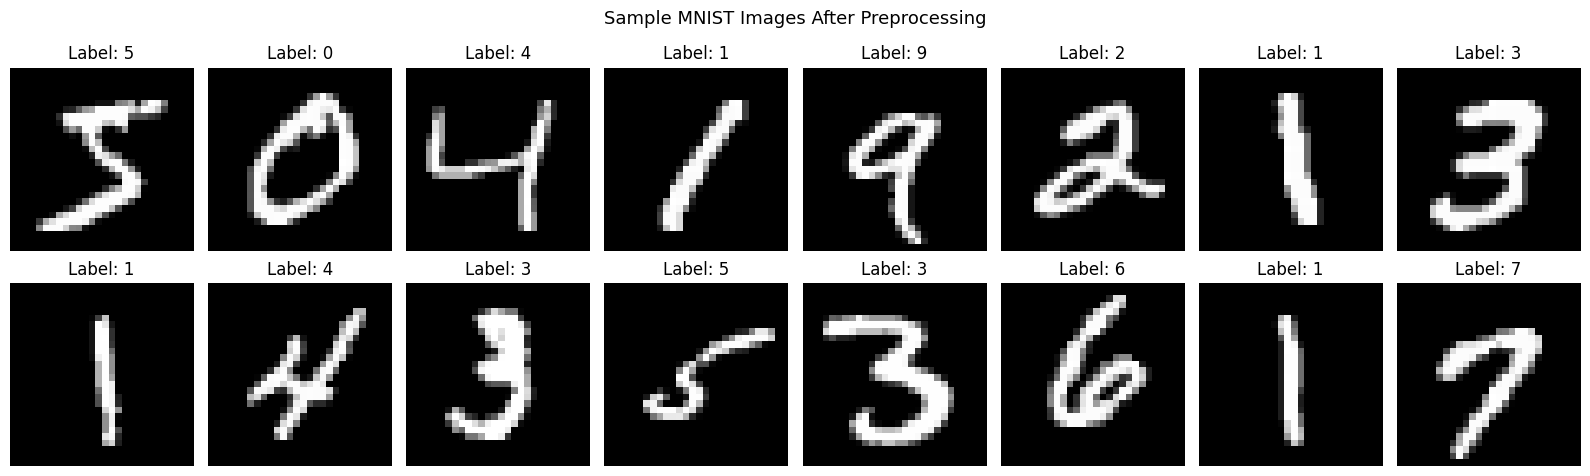

In [9]:
# Always visualize your data before training
# This builds intuition and helps catch preprocessing bugs early
fig, axes = plt.subplots(2, 8, figsize=(16, 5))
fig.suptitle('Sample MNIST Images After Preprocessing', fontsize=13)

for i, ax in enumerate(axes.flat):
    # squeeze() removes the channel dimension (28, 28, 1) -> (28, 28) for display
    ax.imshow(x_train_mnist[i].squeeze(), cmap='gray')
    # argmax on one-hot label gives back the integer digit
    ax.set_title(f'Label: {np.argmax(y_train_mnist[i])}')
    ax.axis('off')

plt.tight_layout()
plt.show()

---
## Section 3: Building the CNN

### How a CNN actually works

A CNN (Convolutional Neural Network) is specifically designed for image data. Here is what each part does:

**Convolutional Layer (Conv2D)**
Slides a small filter (say 3x3 pixels) across the image and computes a dot product at each position.
This creates a feature map that highlights where a certain pattern (edge, curve, corner) exists.
Multiple filters mean multiple feature maps, each detecting something different.

**ReLU Activation**
After each convolution, we apply ReLU (Rectified Linear Unit): f(x) = max(0, x).
This introduces non-linearity. Without it, stacking layers would be equivalent to one linear operation
and the network would not be able to learn complex patterns.

**BatchNormalization**
Normalizes the output of each layer to have zero mean and unit variance.
This stabilizes and speeds up training significantly. Think of it as doing the same thing
we did to pixel values, but internally, after every layer.

**MaxPooling2D**
Takes the maximum value in a 2x2 window and keeps only that, discarding the other 3 values.
This reduces spatial dimensions (shrinks the feature maps) while retaining the most important features.
It also makes the model somewhat invariant to small translations in the input.

**Dropout**
During training, randomly sets a fraction of neurons to zero.
This prevents overfitting: the model cannot memorize training data because different neurons
are dropped each step, forcing the network to learn redundant representations.

**Dense (Fully Connected) Layer**
After convolutions extract spatial features, Dense layers combine them to make the final classification.
The last Dense layer has one neuron per class with Softmax activation, which converts raw scores
into probabilities that sum to 1.

In [10]:
def build_cnn(input_shape, num_classes):
    """
    Build a CNN for image classification.

    Architecture:
        Two convolutional blocks (Conv -> BN -> Conv -> BN -> Pool -> Dropout)
        followed by a fully connected head.

    Parameters:
        input_shape  : tuple, e.g. (28, 28, 1) for grayscale MNIST
        num_classes  : int, number of output classes

    Returns:
        Compiled Keras model
    """
    model = models.Sequential(name='HandwritingCNN')

    # Input layer - explicitly tells Keras the expected input shape
    model.add(layers.Input(shape=input_shape))

    # --- Convolutional Block 1 ---
    # 32 filters of size 3x3. padding='same' keeps output spatial size equal to input
    model.add(layers.Conv2D(32, kernel_size=(3, 3), padding='same', activation='relu'))
    model.add(layers.BatchNormalization())
    model.add(layers.Conv2D(32, kernel_size=(3, 3), padding='same', activation='relu'))
    model.add(layers.BatchNormalization())
    # Pool reduces 28x28 to 14x14 (halved)
    model.add(layers.MaxPooling2D(pool_size=(2, 2)))
    # Dropout of 0.25 means 25% of neurons are randomly zeroed during training
    model.add(layers.Dropout(0.25))

    # --- Convolutional Block 2 ---
    # 64 filters - deeper layers learn more complex features so we use more filters
    model.add(layers.Conv2D(64, kernel_size=(3, 3), padding='same', activation='relu'))
    model.add(layers.BatchNormalization())
    model.add(layers.Conv2D(64, kernel_size=(3, 3), padding='same', activation='relu'))
    model.add(layers.BatchNormalization())
    # Pool reduces 14x14 to 7x7
    model.add(layers.MaxPooling2D(pool_size=(2, 2)))
    model.add(layers.Dropout(0.25))

    # --- Fully Connected Head ---
    # Flatten converts 3D feature maps (7, 7, 64) into a 1D vector of 3136 values
    model.add(layers.Flatten())
    model.add(layers.Dense(256, activation='relu'))
    model.add(layers.BatchNormalization())
    model.add(layers.Dropout(0.5))  # higher dropout before the final layer

    # Output layer: one neuron per class
    # Softmax turns raw scores into a probability distribution
    model.add(layers.Dense(num_classes, activation='softmax'))

    # Compile: defines how the model learns
    # optimizer=Adam adjusts learning rates adaptively (generally best default choice)
    # loss=categorical_crossentropy is standard for multi-class classification with one-hot labels
    # metrics=['accuracy'] tracks human-readable performance during training
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=0.001),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    return model


mnist_model = build_cnn(input_shape=(28, 28, 1), num_classes=10)
mnist_model.summary()

Model: "HandwritingCNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 28, 28, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 28, 28, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 28, 28, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 14, 14, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 14, 14, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 14, 14, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 3136)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       803,072 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 872,426 (3.33 MB)

 Trainable params: 871,530 (3.32 MB)

 Non-trainable params: 896 (3.50 KB)

### Callbacks: The Smart Parts of Training

Callbacks are functions that run at certain points during training (end of each epoch, end of batch, etc.).
We use three here:

**ModelCheckpoint**: Saves the model weights to Drive after each epoch, but only if validation accuracy improved.
This means Drive always has the best version of the model, not just the last one.

**EarlyStopping**: Monitors validation accuracy. If it stops improving for `patience` epochs in a row,
training stops automatically. This saves GPU time and prevents overfitting.

**CSVLogger**: Writes epoch-by-epoch metrics (loss, accuracy) to a CSV file on Drive.
This is important for resuming sessions. You can plot your training curve later even after
the Colab session ended, just by reading the CSV from Drive.

In [11]:
def get_callbacks(model_save_path, log_save_path):
    """
    Returns a list of Keras callbacks for smart training.

    Parameters:
        model_save_path : full path on Drive to save the .h5 weights file
        log_save_path   : full path on Drive to save the training CSV log
    """
    callbacks = [
        # Save only the best model based on val_accuracy
        ModelCheckpoint(
            filepath=model_save_path,
            monitor='val_accuracy',
            save_best_only=True,
            verbose=1
        ),
        # Stop training if val_accuracy does not improve for 5 consecutive epochs
        # restore_best_weights=True loads the best checkpoint before returning
        EarlyStopping(
            monitor='val_accuracy',
            patience=5,
            restore_best_weights=True,
            verbose=1
        ),
        # Save metrics to CSV after each epoch
        # append=True means if the file exists, new rows are added (resume-friendly)
        CSVLogger(log_save_path, append=True)
    ]
    return callbacks

### Smart Resume Logic

This is the most practical part for using Colab's free GPU efficiently.

When you start a new session, we check if trained weights already exist on Drive.
If they do, we load them directly and skip training entirely.
If they do not exist, we train from scratch and save everything to Drive when done.

This means you only ever pay the GPU cost once, no matter how many times the runtime resets.

In [12]:
MNIST_LOG_PATH = os.path.join(HISTORY_DIR, 'mnist_training_log.csv')

if os.path.exists(MNIST_MODEL_PATH):
    # Weights found on Drive - load and skip training
    print(f'Saved MNIST model found at {MNIST_MODEL_PATH}')
    print('Loading weights - no retraining needed.')
    mnist_model.load_weights(MNIST_MODEL_PATH)

else:
    print('No saved model found. Starting training from scratch...')

    mnist_history = mnist_model.fit(
        x_train_mnist, y_train_mnist,
        epochs=30,            # max epochs; EarlyStopping will stop earlier if needed
        batch_size=128,       # process 128 images at once per gradient update step
        validation_split=0.1, # use 10% of training data to monitor generalization
        callbacks=get_callbacks(MNIST_MODEL_PATH, MNIST_LOG_PATH),
        verbose=1
    )

    # Save the history object separately so we can plot it later
    history_path = os.path.join(HISTORY_DIR, 'mnist_history.pkl')
    with open(history_path, 'wb') as f:
        pickle.dump(mnist_history.history, f)

    print(f'Training complete. Model and history saved to Drive.')

No saved model found. Starting training from scratch...
Epoch 1/30
422/422 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.8831 - loss: 0.3861
Epoch 1: val_accuracy improved from None to 0.58883, saving model to /content/drive/MyDrive/handwriting_recognition/models/mnist_cnn.h5



Epoch 1: finished saving model to /content/drive/MyDrive/handwriting_recognition/models/mnist_cnn.h5
422/422 ━━━━━━━━━━━━━━━━━━━━ 23s 27ms/step - accuracy: 0.9459 - loss: 0.1762 - val_accuracy: 0.5888 - val_loss: 1.3340
Epoch 2/30
422/422 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9787 - loss: 0.0661
Epoch 2: val_accuracy improved from 0.58883 to 0.98817, saving model to /content/drive/MyDrive/handwriting_recognition/models/mnist_cnn.h5



Epoch 2: finished saving model to /content/drive/MyDrive/handwriting_recognition/models/mnist_cnn.h5
422/422 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - accuracy: 0.9809 - loss: 0.0603 - val_accuracy: 0.9882 - val_loss: 0.0382
Epoch 3/30
417/422 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9851 - loss: 0.0484
Epoch 3: val_accuracy improved from 0.98817 to 0.99117, saving model to /content/drive/MyDrive/handwriting_recognition/models/mnist_cnn.h5



Epoch 3: finished saving model to /content/drive/MyDrive/handwriting_recognition/models/mnist_cnn.h5
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.9851 - loss: 0.0473 - val_accuracy: 0.9912 - val_loss: 0.0283
Epoch 4/30
418/422 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9881 - loss: 0.0378
Epoch 4: val_accuracy improved from 0.99117 to 0.99250, saving model to /content/drive/MyDrive/handwriting_recognition/models/mnist_cnn.h5



Epoch 4: finished saving model to /content/drive/MyDrive/handwriting_recognition/models/mnist_cnn.h5
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.9888 - loss: 0.0353 - val_accuracy: 0.9925 - val_loss: 0.0265
Epoch 5/30
418/422 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9888 - loss: 0.0335
Epoch 5: val_accuracy did not improve from 0.99250
422/422 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - accuracy: 0.9894 - loss: 0.0323 - val_accuracy: 0.9890 - val_loss: 0.0356
Epoch 6/30
417/422 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9898 - loss: 0.0318
Epoch 6: val_accuracy did not improve from 0.99250
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.9901 - loss: 0.0301 - val_accuracy: 0.9917 - val_loss: 0.0279
Epoch 7/30
419/422 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9921 - loss: 0.0248
Epoch 7: val_accuracy did not improve from 0.99250
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.9919 - loss: 0.0247 - val_accuracy: 0.9913 - val_loss: 0.0292
Epoch 8/30
422


Epoch 9: finished saving model to /content/drive/MyDrive/handwriting_recognition/models/mnist_cnn.h5
422/422 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step - accuracy: 0.9932 - loss: 0.0213 - val_accuracy: 0.9930 - val_loss: 0.0246
Epoch 10/30
418/422 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9937 - loss: 0.0191
Epoch 10: val_accuracy improved from 0.99300 to 0.99317, saving model to /content/drive/MyDrive/handwriting_recognition/models/mnist_cnn.h5



Epoch 10: finished saving model to /content/drive/MyDrive/handwriting_recognition/models/mnist_cnn.h5
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.9939 - loss: 0.0184 - val_accuracy: 0.9932 - val_loss: 0.0234
Epoch 11/30
422/422 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9939 - loss: 0.0186
Epoch 11: val_accuracy did not improve from 0.99317
422/422 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - accuracy: 0.9939 - loss: 0.0184 - val_accuracy: 0.9920 - val_loss: 0.0319
Epoch 12/30
419/422 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9944 - loss: 0.0167
Epoch 12: val_accuracy improved from 0.99317 to 0.99383, saving model to /content/drive/MyDrive/handwriting_recognition/models/mnist_cnn.h5



Epoch 12: finished saving model to /content/drive/MyDrive/handwriting_recognition/models/mnist_cnn.h5
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.9945 - loss: 0.0163 - val_accuracy: 0.9938 - val_loss: 0.0260
Epoch 13/30
421/422 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9955 - loss: 0.0143
Epoch 13: val_accuracy did not improve from 0.99383
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.9954 - loss: 0.0148 - val_accuracy: 0.9932 - val_loss: 0.0275
Epoch 14/30
418/422 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9950 - loss: 0.0144
Epoch 14: val_accuracy did not improve from 0.99383
422/422 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - accuracy: 0.9950 - loss: 0.0141 - val_accuracy: 0.9915 - val_loss: 0.0309
Epoch 15/30
421/422 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9955 - loss: 0.0138
Epoch 15: val_accuracy did not improve from 0.99383
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.9954 - loss: 0.0136 - val_accuracy: 0.9922 - val_loss: 0.0297
Epoch

---
## Section 4: Evaluation and Analysis

A single accuracy number is not enough to understand how well your model works.

The **confusion matrix** shows, for each true class, how many examples were predicted as each class.
Perfect predictions form a bright diagonal. Off-diagonal entries show specific confusions
(e.g., the model often confuses digit 4 with digit 9).

The **classification report** gives precision, recall, and F1-score per class:
- Precision: of all times the model predicted class X, how often was it correct?
- Recall: of all actual class X examples, how many did the model find?
- F1: harmonic mean of precision and recall, balanced measure.

In [13]:
# Evaluate on the held-out test set (the model has never seen these during training)
test_loss, test_acc = mnist_model.evaluate(x_test_mnist, y_test_mnist, verbose=0)
print(f'MNIST Test Accuracy: {test_acc:.4f} ({test_acc*100:.2f}%)')
print(f'MNIST Test Loss:     {test_loss:.4f}')

MNIST Test Accuracy: 0.9943 (99.43%)
MNIST Test Loss:     0.0187


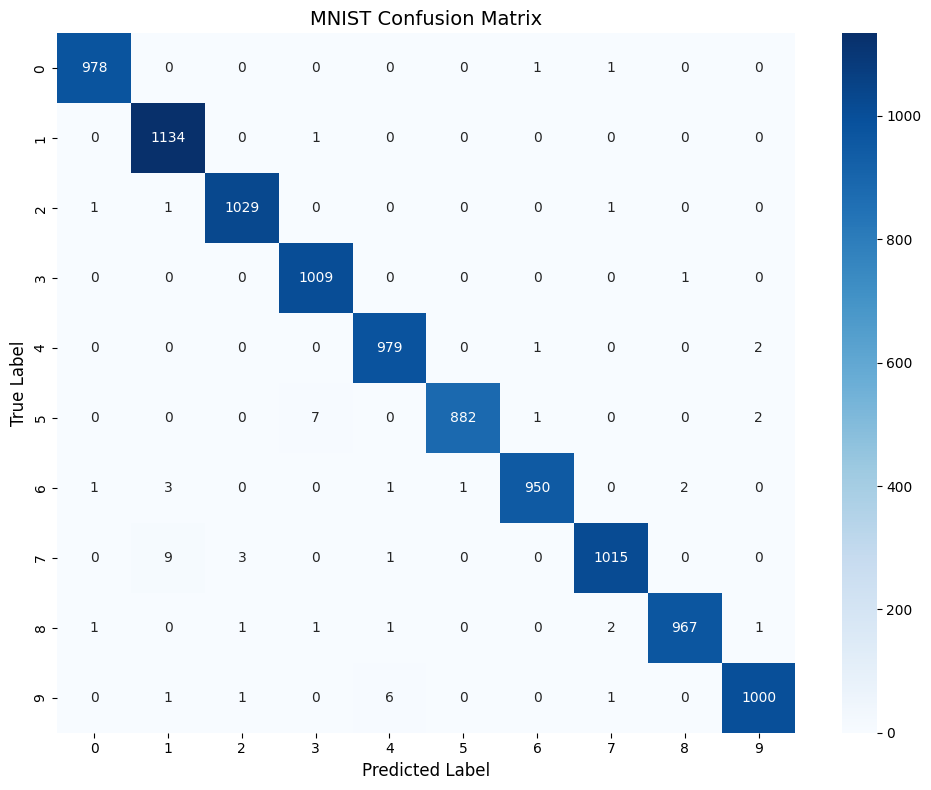


Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       980
           1       0.99      1.00      0.99      1135
           2       1.00      1.00      1.00      1032
           3       0.99      1.00      1.00      1010
           4       0.99      1.00      0.99       982
           5       1.00      0.99      0.99       892
           6       1.00      0.99      0.99       958
           7       1.00      0.99      0.99      1028
           8       1.00      0.99      0.99       974
           9       1.00      0.99      0.99      1009

    accuracy                           0.99     10000
   macro avg       0.99      0.99      0.99     10000
weighted avg       0.99      0.99      0.99     10000



In [14]:
# Get predicted class for every test image
# model.predict returns a probability distribution, argmax gives the predicted class index
y_pred_probs = mnist_model.predict(x_test_mnist, verbose=0)
y_pred       = np.argmax(y_pred_probs, axis=1)
y_true       = np.argmax(y_test_mnist, axis=1)

# Build the confusion matrix
cm_mnist = confusion_matrix(y_true, y_pred)

# Plot it as a heatmap
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(
    cm_mnist,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=range(10),
    yticklabels=range(10),
    ax=ax
)
ax.set_xlabel('Predicted Label', fontsize=12)
ax.set_ylabel('True Label', fontsize=12)
ax.set_title('MNIST Confusion Matrix', fontsize=14)
plt.tight_layout()
plt.show()

# Print per-class metrics
print('\nClassification Report:')
print(classification_report(y_true, y_pred, target_names=[str(i) for i in range(10)]))

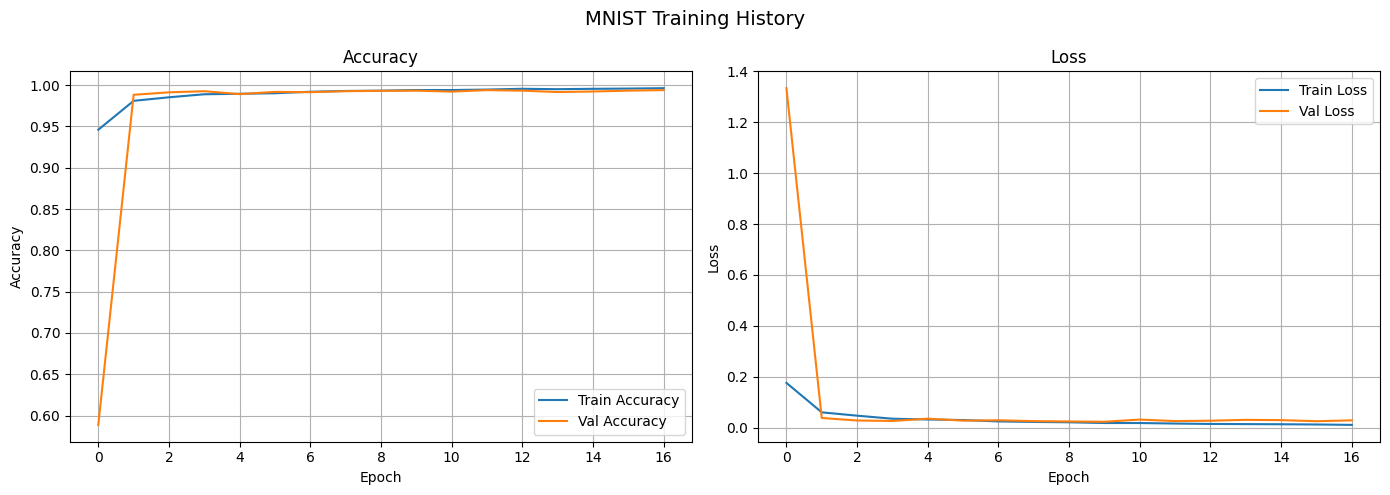

Final train accuracy: 0.9962
Final val accuracy:   0.9938
Generalization gap:   0.0024 (lower is better)


In [15]:
def plot_training_history_from_csv(csv_path, title):
    """
    Load training metrics from a saved CSV and plot the learning curves.
    Works even after a runtime reset because the CSV is on Drive.
    """
    import pandas as pd
    df = pd.read_csv(csv_path)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle(title, fontsize=14)

    # Accuracy curves
    axes[0].plot(df['accuracy'],     label='Train Accuracy')
    axes[0].plot(df['val_accuracy'], label='Val Accuracy')
    axes[0].set_title('Accuracy')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Accuracy')
    axes[0].legend()
    axes[0].grid(True)

    # Loss curves
    axes[1].plot(df['loss'],     label='Train Loss')
    axes[1].plot(df['val_loss'], label='Val Loss')
    axes[1].set_title('Loss')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Loss')
    axes[1].legend()
    axes[1].grid(True)

    plt.tight_layout()
    plt.show()

    # A model that performs much better on training than validation is overfitting
    final_train = df['accuracy'].iloc[-1]
    final_val   = df['val_accuracy'].iloc[-1]
    gap = final_train - final_val
    print(f'Final train accuracy: {final_train:.4f}')
    print(f'Final val accuracy:   {final_val:.4f}')
    print(f'Generalization gap:   {gap:.4f} (lower is better)')


if os.path.exists(MNIST_LOG_PATH):
    plot_training_history_from_csv(MNIST_LOG_PATH, 'MNIST Training History')
else:
    print('Training log not found. Train the model first to generate the log.')

---
## Section 5: Grad-CAM - Understanding What the Model Sees

### The Problem with Black Box Models

After training, we know the model gets 99% accuracy. But why? What parts of the image is it
actually looking at when it makes a decision? Without this, we cannot trust the model
and we cannot debug it if it makes mistakes.

### What is Grad-CAM?

Grad-CAM (Gradient-weighted Class Activation Mapping) is an interpretability technique.
It produces a heatmap highlighting which regions of the input image were most important
for the model's prediction.

### How it works (step by step)

1. Pick a convolutional layer (usually the last one - it has the most semantic features)
2. Run the image through the model up to that layer, capturing the feature maps
3. Compute the gradient of the predicted class score with respect to those feature maps
   (this tells us: if we slightly increase each feature map value, how does the class score change?)
4. Average the gradients over the spatial dimensions to get an importance weight per filter
5. Take a weighted sum of the feature maps using those weights
6. Apply ReLU to keep only positive contributions
7. Resize to original image size and overlay as a heatmap

The result is a visual explanation: red areas contributed most to the prediction.

In [24]:
def compute_gradcam(model, image, class_index, last_conv_layer_name):
    """
    Compute Grad-CAM heatmap for a given image and predicted class.

    Parameters:
        model               : trained Keras model
        image               : single preprocessed image, shape (1, H, W, C)
        class_index         : integer index of the class to explain
        last_conv_layer_name: name of the last conv layer in the model

    Returns:
        heatmap: numpy array of shape (H, W) with values in [0, 1]
    """
    num_classes = model.output_shape[-1] # Number of output classes

    # Ensure model is built, if not already (e.g., if loaded weights only)
    if not model.built:
        # Use a dummy input to build the model if it hasn't been built by data.
        # This ensures model.input and layer.output properties are initialized.
        model.build((None,) + image.shape[1:]) # Batch dim can be None

    # 1. Create a model that maps the input image to the activations of the last conv layer
    #    We use model.layers[0].input as it was found to be more robust than model.input
    feature_extractor = keras.Model(
        inputs=model.layers[0].input,
        outputs=model.get_layer(last_conv_layer_name).output
    )

    # 2. Create a sub-model (classifier_model) that takes the output of the last conv layer
    #    and maps it to the final predictions. This reconstructs the "head" of the model.
    classifier_input = keras.Input(shape=feature_extractor.output_shape[1:]) # Shape excluding batch dim (H, W, Filters)
    x = classifier_input
    add_layers = False
    for layer in model.layers:
        if layer.name == last_conv_layer_name:
            add_layers = True # Start adding layers *after* the last conv layer
            continue
        if add_layers:
            # Reconstruct the layers after the last conv layer. Keras reuses weights.
            x = layer(x)
    classifier_model = keras.Model(inputs=classifier_input, outputs=x)

    with tf.GradientTape() as tape:
        # Pass the input image through the feature extractor to get conv_outputs
        conv_outputs = feature_extractor(image)
        tape.watch(conv_outputs) # Explicitly watch intermediate activations

        # Pass the extracted features through the classifier part to get predictions
        predictions = classifier_model(conv_outputs)

        # Score for the specific class we want to explain
        class_score = predictions[:, class_index]

    # Gradient of class score w.r.t. the conv feature maps
    grads = tape.gradient(class_score, conv_outputs)

    # Check if gradients are None (should be prevented by this new structure)
    if grads is None:
        raise ValueError("Gradients are None. This indicates a problem in tracing the computational graph.")

    # Average gradient over spatial dimensions (H, W) for each filter
    # This gives one importance weight per filter
    # axes=[0, 1, 2] averages over batch, height, width -> shape: (num_filters,)
    pooled_grads = tf.reduce_mean(grads, axis=[0, 1, 2])

    # Remove batch dimension: (1, H, W, num_filters) -> (H, W, num_filters)
    conv_outputs = conv_outputs[0]

    # Weighted sum: multiply each filter map by its importance weight
    # heatmap shape: (H, W)
    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)

    # Apply ReLU: only keep positive activations
    # Negative values mean 'this region works against this class' - we ignore those
    heatmap = tf.maximum(heatmap, 0)

    # Normalize to [0, 1] for visualization
    heatmap = heatmap.numpy()
    if heatmap.max() > 0:
        heatmap = heatmap / heatmap.max()

    return heatmap

def overlay_gradcam(original_image, heatmap):
    """
    Resize heatmap to match the original image and overlay as a color map.

    Parameters:
        original_image : numpy array (H, W) or (H, W, 1), grayscale
        heatmap        : numpy array from compute_gradcam, values in [0, 1]

    Returns:
        superimposed: RGB image (H, W, 3) ready to display
    """
    img_h, img_w = original_image.shape[:2]

    # Resize heatmap to match input image size using bilinear interpolation
    heatmap_resized = cv2.resize(heatmap, (img_w, img_h))

    # Apply a colormap (COLORMAP_JET: blue=low, red=high importance)
    heatmap_colored = cv2.applyColorMap(
        np.uint8(255 * heatmap_resized), cv2.COLORMAP_JET
    )
    # cv2 uses BGR, convert to RGB for matplotlib
    heatmap_colored = cv2.cvtColor(heatmap_colored, cv2.COLOR_BGR2RGB)

    # Convert original grayscale image to RGB for blending
    img_rgb = np.squeeze(original_image)
    img_rgb = np.stack([img_rgb * 255] * 3, axis=-1).astype(np.uint8)

    # Superimpose: blend original image with heatmap at 40% opacity
    superimposed = (heatmap_colored * 0.4 + img_rgb * 0.6).astype(np.uint8)

    return superimposed

Last Conv2D layer: conv2d_3


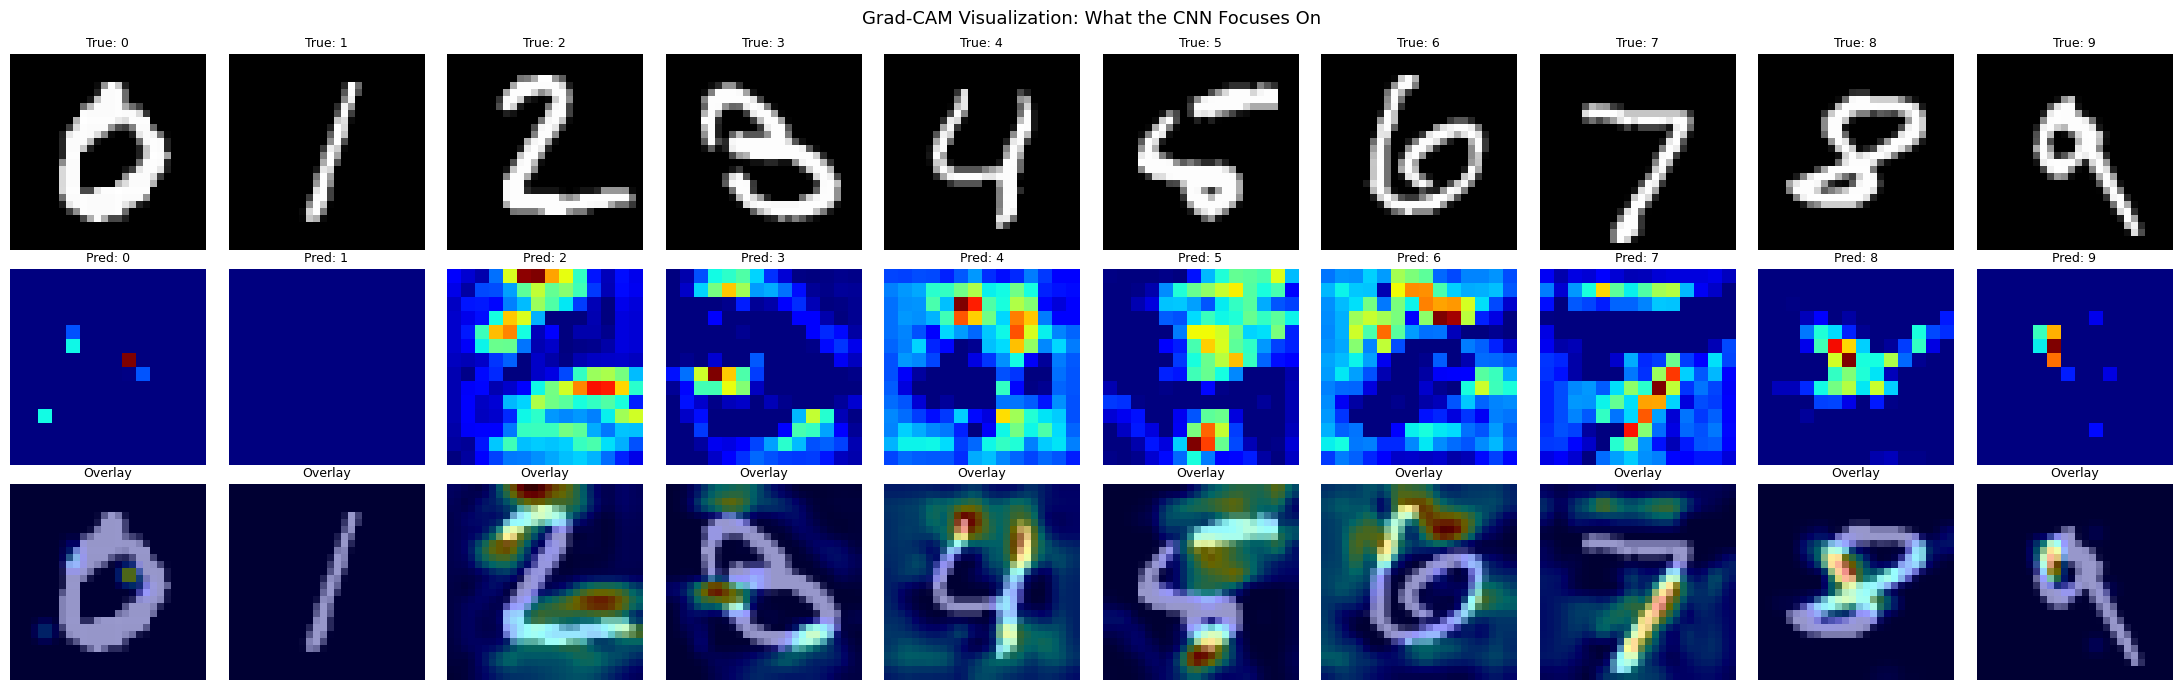

Row 1: Original | Row 2: Heatmap (red = most important) | Row 3: Overlay


In [25]:
# Find the name of the last Conv2D layer in our model
# We need this to tell Grad-CAM which layer to attach to
last_conv_name = None
for layer in reversed(mnist_model.layers):
    if isinstance(layer, layers.Conv2D):
        last_conv_name = layer.name
        break

print(f'Last Conv2D layer: {last_conv_name}')

# Visualize Grad-CAM for 10 test images (one per digit)
fig, axes = plt.subplots(3, 10, figsize=(22, 7))
fig.suptitle('Grad-CAM Visualization: What the CNN Focuses On', fontsize=13)

# Collect one example per digit class
digit_indices = []
for digit in range(10):
    idx = np.where(y_true == digit)[0][0]
    digit_indices.append(idx)

for col, idx in enumerate(digit_indices):
    img   = x_test_mnist[idx:idx+1]  # shape (1, 28, 28, 1)
    pred  = np.argmax(mnist_model.predict(img, verbose=0))
    hmap  = compute_gradcam(mnist_model, img, pred, last_conv_name)
    overlay = overlay_gradcam(img[0], hmap)

    # Row 0: original image
    axes[0, col].imshow(img[0].squeeze(), cmap='gray')
    axes[0, col].set_title(f'True: {y_true[idx]}', fontsize=9)
    axes[0, col].axis('off')

    # Row 1: raw heatmap
    axes[1, col].imshow(hmap, cmap='jet')
    axes[1, col].set_title(f'Pred: {pred}', fontsize=9)
    axes[1, col].axis('off')

    # Row 2: overlay
    axes[2, col].imshow(overlay)
    axes[2, col].set_title('Overlay', fontsize=9)
    axes[2, col].axis('off')

plt.tight_layout()
plt.show()
print('Row 1: Original | Row 2: Heatmap (red = most important) | Row 3: Overlay')

---
## Section 6: EMNIST - Scaling to Full Characters

### What is EMNIST?

EMNIST (Extended MNIST) extends the MNIST format to include handwritten letters.
We use the 'balanced' split which has 47 classes: digits 0-9, uppercase A-Z, and
lowercase letters that are visually distinct from their uppercase equivalents.
Some like C/c, O/o are merged since they look identical in handwriting.

It has ~112,800 training examples and ~18,800 test examples.

### What changes compared to MNIST?

The CNN architecture is identical. We only change:
- num_classes: 10 -> 47
- The label mapping: digits map directly, but letters need a lookup table
- Slightly more training time due to more classes

This is intentional. Good architectures are reusable. Understanding why the same CNN
works for both cases is as important as writing the code.

In [26]:
EMNIST_CACHE = os.path.join(DATASET_DIR, 'emnist_balanced.npz')

if os.path.exists(EMNIST_CACHE):
    # Load the pre-saved dataset from Drive to skip re-downloading
    print('Loading EMNIST from Drive cache...')
    data = np.load(EMNIST_CACHE)
    x_train_em = data['x_train']
    y_train_em = data['y_train']
    x_test_em  = data['x_test']
    y_test_em  = data['y_test']

else:
    print('Downloading EMNIST for the first time...')

    # tensorflow_datasets provides a clean API to download and stream standard datasets
    ds_train, ds_test = tfds.load(
        'emnist/balanced',
        split=['train', 'test'],
        as_supervised=True
    )

    # Convert TF datasets to numpy arrays for easier manipulation
    def tfds_to_numpy(dataset):
        images, labels = [], []
        for img, lbl in dataset:
            images.append(img.numpy())
            labels.append(lbl.numpy())
        return np.array(images), np.array(labels)

    x_train_em, y_train_em = tfds_to_numpy(ds_train)
    x_test_em,  y_test_em  = tfds_to_numpy(ds_test)

    # Save to Drive so we never download again
    np.savez_compressed(
        EMNIST_CACHE,
        x_train=x_train_em, y_train=y_train_em,
        x_test=x_test_em,   y_test=y_test_em
    )
    print(f'EMNIST saved to Drive at {EMNIST_CACHE}')

print(f'Train shape: {x_train_em.shape} | Test shape: {x_test_em.shape}')
print(f'Number of classes: {len(np.unique(y_train_em))}')

Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Extraction completed...: 0 file [00:00, ? file/s]

Extraction completed...: 0 file [00:00, ? file/s]

Generating splits...:   0%|          | 0/2 [00:00<?, ? splits/s]

Generating train examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/emnist/balanced/incomplete.JBH0NY_3.1.0/emnist-train.tfrecord*...:   0%|  …

Generating test examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/emnist/balanced/incomplete.JBH0NY_3.1.0/emnist-test.tfrecord*...:   0%|   …

Dataset emnist downloaded and prepared to /root/tensorflow_datasets/emnist/balanced/3.1.0. Subsequent calls will reuse this data.
EMNIST saved to Drive at /content/drive/MyDrive/handwriting_recognition/datasets/emnist_balanced.npz
Train shape: (112800, 28, 28, 1) | Test shape: (18800, 28, 28, 1)
Number of classes: 47


In [27]:
# EMNIST images from tensorflow_datasets come as (28, 28, 1) already
# but they are stored as uint8, so we normalize and one-hot encode

EMNIST_CLASSES = 47

# The EMNIST balanced split uses a specific label mapping
# Labels 0-9 = digits, 10-35 = A-Z uppercase, 36-46 = distinct lowercase letters
EMNIST_LABEL_MAP = (
    '0123456789'
    'ABCDEFGHIJKLMNOPQRSTUVWXYZ'
    'abdefghnqrt'  # the 11 lowercase letters that differ visually from uppercase
)

def preprocess_emnist(x_train, y_train, x_test, y_test, num_classes):
    # Normalize to [0, 1]
    x_train = x_train.astype('float32') / 255.0
    x_test  = x_test.astype('float32')  / 255.0

    # EMNIST images from TFDS already have shape (28, 28, 1) but let's make sure
    if x_train.ndim == 3:
        x_train = x_train[..., np.newaxis]
        x_test  = x_test[..., np.newaxis]

    # EMNIST images are stored transposed relative to how we normally see them
    # We rotate 90 degrees and flip to get the correct orientation
    x_train = np.array([np.fliplr(np.rot90(img)) for img in x_train])
    x_test  = np.array([np.fliplr(np.rot90(img)) for img in x_test])

    y_train = keras.utils.to_categorical(y_train, num_classes)
    y_test  = keras.utils.to_categorical(y_test,  num_classes)

    return x_train, y_train, x_test, y_test


x_train_em, y_train_em, x_test_em, y_test_em = preprocess_emnist(
    x_train_em, y_train_em, x_test_em, y_test_em, num_classes=EMNIST_CLASSES
)

print(f'x_train_em shape: {x_train_em.shape}')
print(f'y_train_em shape: {y_train_em.shape}')

x_train_em shape: (112800, 28, 28, 1)
y_train_em shape: (112800, 47)


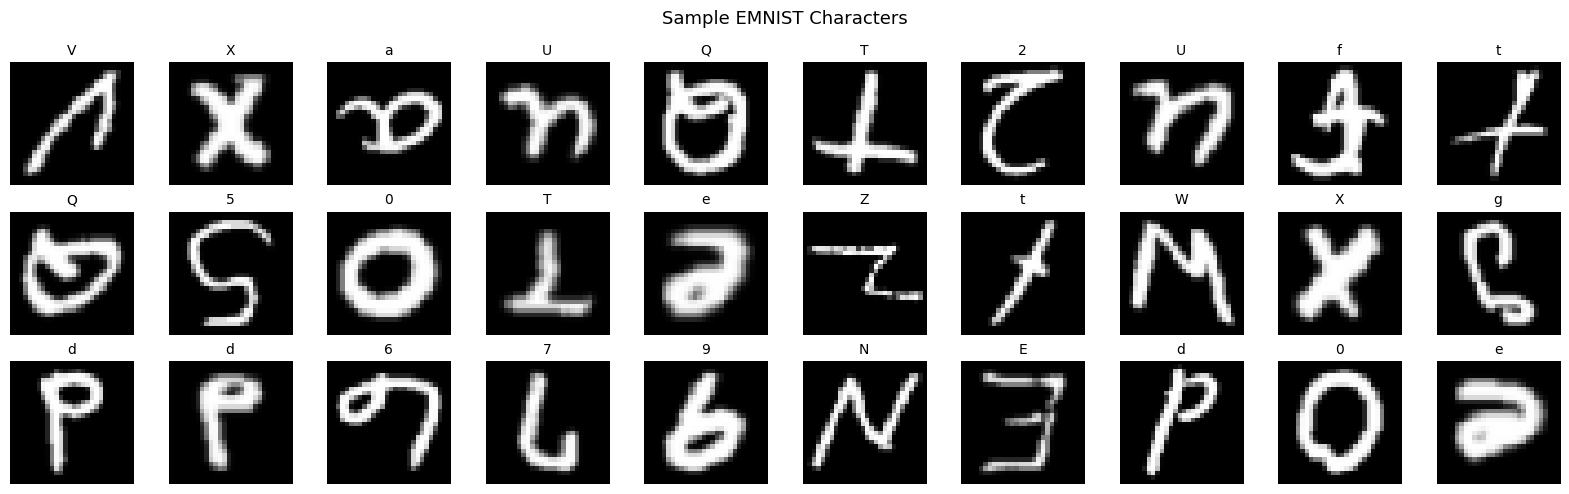

In [28]:
# Visualize a sample of EMNIST characters to verify orientation is correct
fig, axes = plt.subplots(3, 10, figsize=(16, 5))
fig.suptitle('Sample EMNIST Characters', fontsize=13)

for i, ax in enumerate(axes.flat):
    ax.imshow(x_train_em[i * 50].squeeze(), cmap='gray')
    label_idx = np.argmax(y_train_em[i * 50])
    ax.set_title(EMNIST_LABEL_MAP[label_idx], fontsize=10)
    ax.axis('off')

plt.tight_layout()
plt.show()

In [29]:
EMNIST_LOG_PATH = os.path.join(HISTORY_DIR, 'emnist_training_log.csv')

# Build a new model instance for EMNIST (same architecture, 47 output classes)
emnist_model = build_cnn(input_shape=(28, 28, 1), num_classes=EMNIST_CLASSES)

if os.path.exists(EMNIST_MODEL_PATH):
    print(f'Saved EMNIST model found. Loading weights from Drive...')
    emnist_model.load_weights(EMNIST_MODEL_PATH)

else:
    print('Training EMNIST model from scratch...')

    emnist_history = emnist_model.fit(
        x_train_em, y_train_em,
        epochs=40,            # EMNIST is harder (more classes) so we give it more epochs
        batch_size=128,
        validation_split=0.1,
        callbacks=get_callbacks(EMNIST_MODEL_PATH, EMNIST_LOG_PATH),
        verbose=1
    )

    history_path = os.path.join(HISTORY_DIR, 'emnist_history.pkl')
    with open(history_path, 'wb') as f:
        pickle.dump(emnist_history.history, f)

    print('EMNIST training complete. Model and history saved to Drive.')

Training EMNIST model from scratch...
Epoch 1/40
794/794 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.6321 - loss: 1.3463
Epoch 1: val_accuracy improved from None to 0.85488, saving model to /content/drive/MyDrive/handwriting_recognition/models/emnist_cnn.h5



Epoch 1: finished saving model to /content/drive/MyDrive/handwriting_recognition/models/emnist_cnn.h5
794/794 ━━━━━━━━━━━━━━━━━━━━ 25s 19ms/step - accuracy: 0.7483 - loss: 0.8332 - val_accuracy: 0.8549 - val_loss: 0.4141
Epoch 2/40
793/794 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.8369 - loss: 0.4807
Epoch 2: val_accuracy improved from 0.85488 to 0.87465, saving model to /content/drive/MyDrive/handwriting_recognition/models/emnist_cnn.h5



Epoch 2: finished saving model to /content/drive/MyDrive/handwriting_recognition/models/emnist_cnn.h5
794/794 ━━━━━━━━━━━━━━━━━━━━ 29s 12ms/step - accuracy: 0.8429 - loss: 0.4611 - val_accuracy: 0.8746 - val_loss: 0.3513
Epoch 3/40
793/794 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.8573 - loss: 0.4073
Epoch 3: val_accuracy improved from 0.87465 to 0.88262, saving model to /content/drive/MyDrive/handwriting_recognition/models/emnist_cnn.h5



Epoch 3: finished saving model to /content/drive/MyDrive/handwriting_recognition/models/emnist_cnn.h5
794/794 ━━━━━━━━━━━━━━━━━━━━ 9s 11ms/step - accuracy: 0.8594 - loss: 0.4032 - val_accuracy: 0.8826 - val_loss: 0.3274
Epoch 4/40
791/794 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.8661 - loss: 0.3748
Epoch 4: val_accuracy improved from 0.88262 to 0.88555, saving model to /content/drive/MyDrive/handwriting_recognition/models/emnist_cnn.h5



Epoch 4: finished saving model to /content/drive/MyDrive/handwriting_recognition/models/emnist_cnn.h5
794/794 ━━━━━━━━━━━━━━━━━━━━ 11s 12ms/step - accuracy: 0.8683 - loss: 0.3729 - val_accuracy: 0.8855 - val_loss: 0.3259
Epoch 5/40
791/794 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.8724 - loss: 0.3500
Epoch 5: val_accuracy improved from 0.88555 to 0.88892, saving model to /content/drive/MyDrive/handwriting_recognition/models/emnist_cnn.h5



Epoch 5: finished saving model to /content/drive/MyDrive/handwriting_recognition/models/emnist_cnn.h5
794/794 ━━━━━━━━━━━━━━━━━━━━ 8s 11ms/step - accuracy: 0.8727 - loss: 0.3533 - val_accuracy: 0.8889 - val_loss: 0.3095
Epoch 6/40
794/794 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.8753 - loss: 0.3396
Epoch 6: val_accuracy did not improve from 0.88892
794/794 ━━━━━━━━━━━━━━━━━━━━ 9s 11ms/step - accuracy: 0.8767 - loss: 0.3383 - val_accuracy: 0.8885 - val_loss: 0.3086
Epoch 7/40
790/794 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.8810 - loss: 0.3225
Epoch 7: val_accuracy improved from 0.88892 to 0.89051, saving model to /content/drive/MyDrive/handwriting_recognition/models/emnist_cnn.h5



Epoch 7: finished saving model to /content/drive/MyDrive/handwriting_recognition/models/emnist_cnn.h5
794/794 ━━━━━━━━━━━━━━━━━━━━ 10s 12ms/step - accuracy: 0.8816 - loss: 0.3230 - val_accuracy: 0.8905 - val_loss: 0.3019
Epoch 8/40
794/794 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.8826 - loss: 0.3130
Epoch 8: val_accuracy did not improve from 0.89051
794/794 ━━━━━━━━━━━━━━━━━━━━ 8s 10ms/step - accuracy: 0.8833 - loss: 0.3137 - val_accuracy: 0.8904 - val_loss: 0.2976
Epoch 9/40
790/794 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.8885 - loss: 0.2994
Epoch 9: val_accuracy improved from 0.89051 to 0.89255, saving model to /content/drive/MyDrive/handwriting_recognition/models/emnist_cnn.h5



Epoch 9: finished saving model to /content/drive/MyDrive/handwriting_recognition/models/emnist_cnn.h5
794/794 ━━━━━━━━━━━━━━━━━━━━ 10s 12ms/step - accuracy: 0.8894 - loss: 0.2996 - val_accuracy: 0.8926 - val_loss: 0.2964
Epoch 10/40
790/794 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.8883 - loss: 0.2968
Epoch 10: val_accuracy improved from 0.89255 to 0.89512, saving model to /content/drive/MyDrive/handwriting_recognition/models/emnist_cnn.h5



Epoch 10: finished saving model to /content/drive/MyDrive/handwriting_recognition/models/emnist_cnn.h5
794/794 ━━━━━━━━━━━━━━━━━━━━ 9s 11ms/step - accuracy: 0.8896 - loss: 0.2958 - val_accuracy: 0.8951 - val_loss: 0.2980
Epoch 11/40
791/794 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.8936 - loss: 0.2850
Epoch 11: val_accuracy did not improve from 0.89512
794/794 ━━━━━━━━━━━━━━━━━━━━ 8s 11ms/step - accuracy: 0.8943 - loss: 0.2836 - val_accuracy: 0.8920 - val_loss: 0.2964
Epoch 12/40
790/794 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.8949 - loss: 0.2778
Epoch 12: val_accuracy did not improve from 0.89512
794/794 ━━━━━━━━━━━━━━━━━━━━ 9s 11ms/step - accuracy: 0.8962 - loss: 0.2771 - val_accuracy: 0.8946 - val_loss: 0.2927
Epoch 13/40
794/794 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.8972 - loss: 0.2679
Epoch 13: val_accuracy did not improve from 0.89512
794/794 ━━━━━━━━━━━━━━━━━━━━ 8s 10ms/step - accuracy: 0.8969 - loss: 0.2689 - val_accuracy: 0.8933 - val_loss: 0.3004
Epoc

EMNIST Test Accuracy: 0.8919 (89.19%)
EMNIST Test Loss:     0.3153


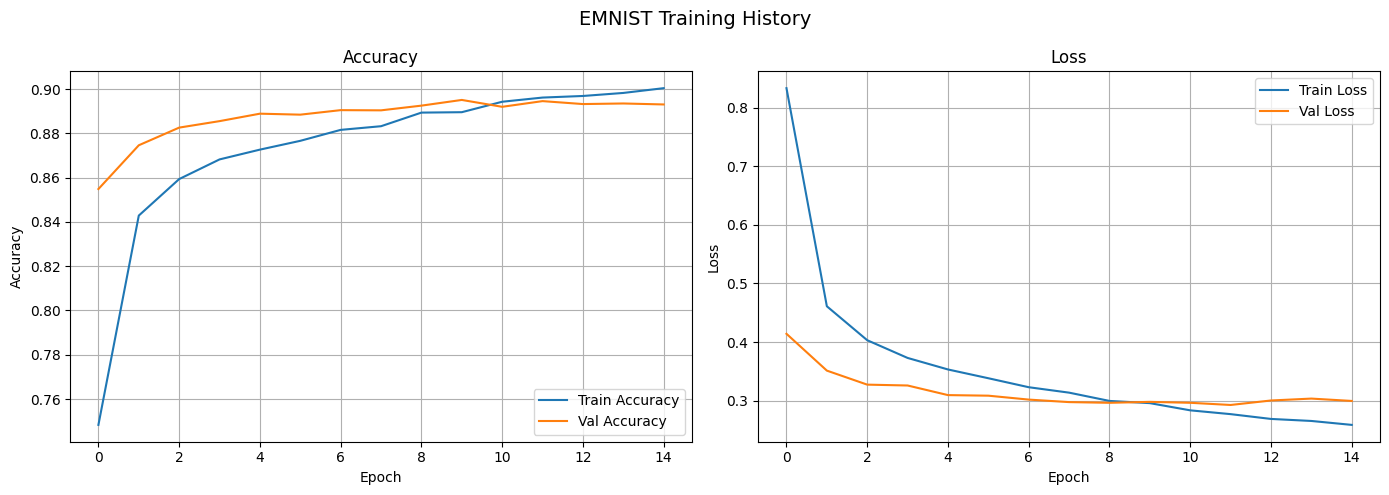

Final train accuracy: 0.9004
Final val accuracy:   0.8931
Generalization gap:   0.0074 (lower is better)


In [30]:
# Evaluate EMNIST model
test_loss_em, test_acc_em = emnist_model.evaluate(x_test_em, y_test_em, verbose=0)
print(f'EMNIST Test Accuracy: {test_acc_em:.4f} ({test_acc_em*100:.2f}%)')
print(f'EMNIST Test Loss:     {test_loss_em:.4f}')

# Note: EMNIST accuracy will be lower than MNIST (typically ~85-88% vs ~99%)
# This is expected because:
# 1. Many more classes (47 vs 10)
# 2. Some character pairs look very similar (e.g., 0 and O, 1 and l and I)
# 3. More variation in human handwriting for letters than digits

if os.path.exists(EMNIST_LOG_PATH):
    plot_training_history_from_csv(EMNIST_LOG_PATH, 'EMNIST Training History')

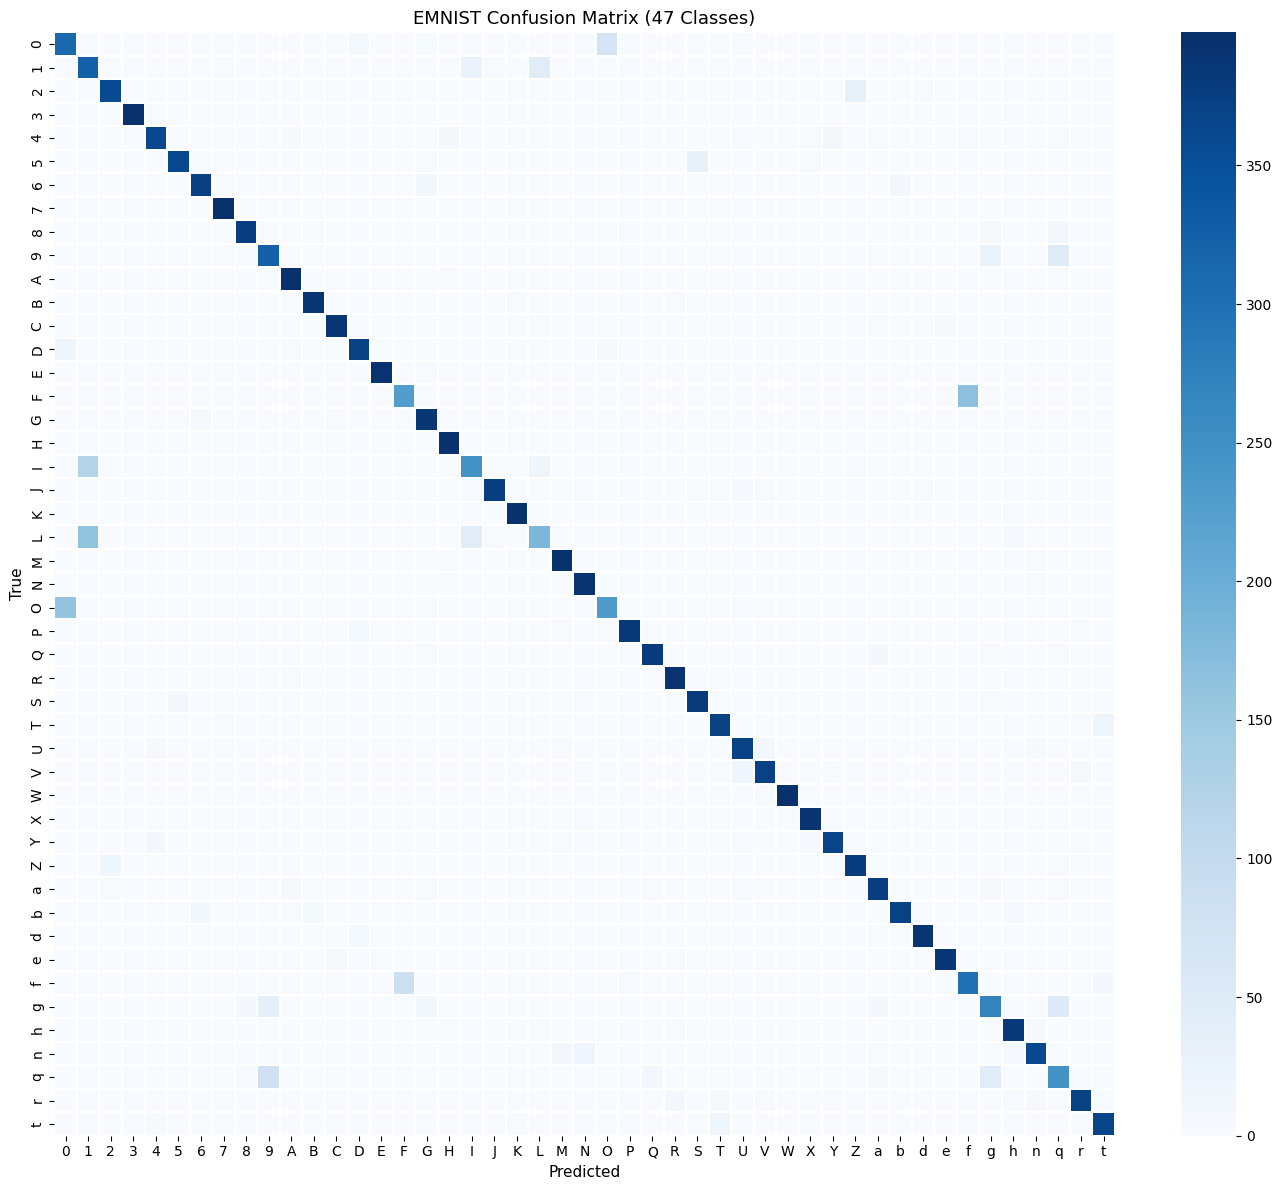

Top 5 most confused character pairs (True -> Predicted):
  F -> f : 167 times
  L -> 1 : 161 times
  O -> 0 : 159 times
  I -> 1 : 124 times
  f -> F : 84 times


In [31]:
# Confusion matrix for EMNIST
y_pred_em_probs = emnist_model.predict(x_test_em, verbose=0)
y_pred_em = np.argmax(y_pred_em_probs, axis=1)
y_true_em = np.argmax(y_test_em, axis=1)

cm_em = confusion_matrix(y_true_em, y_pred_em)

# With 47 classes the matrix is large - we plot it without per-cell numbers
fig, ax = plt.subplots(figsize=(14, 12))
sns.heatmap(
    cm_em,
    cmap='Blues',
    xticklabels=list(EMNIST_LABEL_MAP),
    yticklabels=list(EMNIST_LABEL_MAP),
    ax=ax,
    linewidths=0.3
)
ax.set_xlabel('Predicted', fontsize=11)
ax.set_ylabel('True', fontsize=11)
ax.set_title('EMNIST Confusion Matrix (47 Classes)', fontsize=13)
plt.tight_layout()
plt.show()

# Find the most commonly confused pairs
cm_no_diag = cm_em.copy()
np.fill_diagonal(cm_no_diag, 0)
top5_idx = np.dstack(np.unravel_index(np.argsort(cm_no_diag.ravel())[-5:], cm_no_diag.shape))[0]

print('Top 5 most confused character pairs (True -> Predicted):')
for true_idx, pred_idx in reversed(top5_idx):
    count = cm_no_diag[true_idx, pred_idx]
    print(f'  {EMNIST_LABEL_MAP[true_idx]} -> {EMNIST_LABEL_MAP[pred_idx]} : {count} times')

---
## Section 7: CRNN - From Characters to Words

### The Limitation of CNN-only Approaches

Our CNN classifies one character at a time from a fixed-size 28x28 image.
Real-world handwriting is different: characters have variable width, words do not have
neat boundaries, and letters naturally flow into each other.

To recognize full words or sentences, we need a model that can:
1. Handle variable-length input images (different word lengths)
2. Output variable-length sequences of characters
3. Not require knowing where each character starts and ends (no segmentation)

This is where CRNN (Convolutional Recurrent Neural Network) comes in.

### CRNN Architecture

A CRNN has three components stacked together:

**1. Convolutional Layers (feature extraction)**
Same idea as before: extract visual features from the image.
But now the input image is wider (e.g., 32x128 for a word image).
The Conv layers produce a feature map of shape (H, W, C).
We collapse the height dimension to get a sequence of feature vectors,
one per column of the image. Each column represents a small time-step along the word.

**2. Recurrent Layers (sequence modeling)**
The sequence of column feature vectors is fed into a Bidirectional LSTM.
LSTM (Long Short-Term Memory) is a type of RNN that learns dependencies between
positions in the sequence. Bidirectional means it processes the sequence both
left-to-right AND right-to-left, giving each position context from both directions.

**3. CTC Loss (Connectionist Temporal Classification)**
The LSTM outputs a character probability at each time step.
The number of time steps does not equal the number of characters in the word.
CTC loss handles this by learning to align the output sequence to the target text
without needing explicit character-position labels.
CTC introduces a special 'blank' token and allows repeated characters,
then collapses them during decoding.

Example: The word 'hello' might decode from: [h, h, e, -, l, l, l, -, -, o]
where - is blank. CTC collapses this to: h, e, l, l, o = 'hello'.

In [33]:
def build_crnn(img_height, img_width, num_chars, max_label_length):
    """
    Build a CRNN model for word-level handwriting recognition.

    This is an ARCHITECTURE DEMONSTRATION. The model is not trained here
    because that requires a word-level dataset (e.g., IAM Handwriting Database)
    which takes significant time and GPU resources to process.

    Understanding the shape transformations at each step is the key learning goal.

    Parameters:
        img_height      : height of word images (typically 32)
        img_width       : width of word images (typically 128, variable in practice)
        num_chars       : vocabulary size (e.g., 79 for printable ASCII)
        max_label_length: maximum word length in the dataset

    Returns:
        model        : the CRNN Keras model
        ctc_model    : model wrapped with CTC loss for training
    """

    # --- Input ---
    # Images of shape (height, width, 1) - grayscale word images
    inputs = layers.Input(shape=(img_height, img_width, 1), name='image_input')

    # --- Convolutional Feature Extraction ---
    # These convolution blocks work identically to our character CNN
    # but the image is wider so more columns = more time steps for the LSTM

    x = layers.Conv2D(32, (3, 3), padding='same', activation='relu', name='conv_1')(inputs)
    x = layers.BatchNormalization(name='bn_1')(x)
    x = layers.MaxPooling2D((2, 2), name='pool_1')(x)
    # Shape: (batch, H/2, W/2, 32) -> for 32x128: (batch, 16, 64, 32)

    x = layers.Conv2D(64, (3, 3), padding='same', activation='relu', name='conv_2')(x)
    x = layers.BatchNormalization(name='bn_2')(x)
    x = layers.MaxPooling2D((2, 2), name='pool_2')(x)
    # Shape: (batch, H/4, W/4, 64) -> for 32x128: (batch, 8, 32, 64)

    x = layers.Conv2D(128, (3, 3), padding='same', activation='relu', name='conv_3')(x)
    x = layers.BatchNormalization(name='bn_3')(x)
    # Shape: (batch, 8, 32, 128)

    # --- Bridge: Feature Maps to Sequence ---
    # We need to go from (batch, H, W, C) to (batch, time_steps, features)
    # Reshape collapses the height and channel dimensions together
    # Each column of the feature map becomes one time step for the LSTM

    new_shape = (x.shape[2], x.shape[1] * x.shape[3])  # (W, H*C) = (32, 8*128) = (32, 1024)
    x = layers.Reshape(target_shape=new_shape, name='reshape_to_sequence')(x)
    # Shape: (batch, 32, 1024) - 32 time steps, 1024 features each

    # Optional dense layer to reduce feature dimension before LSTM
    x = layers.Dense(64, activation='relu', name='dense_bridge')(x)
    # Shape: (batch, 32, 64)

    # --- Bidirectional LSTM ---
    # return_sequences=True: output a hidden state at every time step, not just the last
    # This is essential because we need a character probability at every column

    x = layers.Bidirectional(
        layers.LSTM(128, return_sequences=True, dropout=0.25),
        name='bilstm_1'
    )(x)
    # Shape: (batch, 32, 256)  <- 128 * 2 because bidirectional

    x = layers.Bidirectional(
        layers.LSTM(64, return_sequences=True, dropout=0.25),
        name='bilstm_2'
    )(x)
    # Shape: (batch, 32, 128)

    # --- Output Layer ---
    # num_chars + 1 because CTC requires a special blank token
    # Softmax gives probabilities over the character vocabulary at each time step
    output = layers.Dense(num_chars + 1, activation='softmax', name='ctc_output')(x)
    # Shape: (batch, 32, num_chars + 1)

    # The base model takes an image and produces per-timestep character probabilities
    model = keras.Model(inputs=inputs, outputs=output, name='CRNN_base')

    return model


# Build the model to verify shapes are correct
crnn = build_crnn(
    img_height=32,
    img_width=128,
    num_chars=79,      # printable ASCII characters
    max_label_length=16
)

crnn.summary()

Model: "CRNN_base"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ image_input (InputLayer)        │ (None, 32, 128, 1)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_1 (Conv2D)                 │ (None, 32, 128, 32)    │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_1 (BatchNormalization)       │ (None, 32, 128, 32)    │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool_1 (MaxPooling2D)           │ (None, 16, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_2 (Conv2D)                 │ (None, 16, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_2 (BatchNormalization)       │ (None, 16, 64, 64)     │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool_2 (MaxPooling2D)           │ (None, 8, 32, 64)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_3 (Conv2D)                 │ (None, 8, 32, 128)     │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_3 (BatchNormalization)       │ (None, 8, 32, 128)     │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape_to_sequence (Reshape)   │ (None, 32, 1024)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_bridge (Dense)            │ (None, 32, 64)         │        65,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bilstm_1 (Bidirectional)        │ (None, 32, 256)        │       197,632 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bilstm_2 (Bidirectional)        │ (None, 32, 128)        │       164,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ ctc_output (Dense)              │ (None, 32, 80)         │        10,320 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 531,472 (2.03 MB)

 Trainable params: 531,024 (2.03 MB)

 Non-trainable params: 448 (1.75 KB)

In [34]:
# CTC Loss Implementation
# This is what makes CRNN trainable without needing character-level segmentation

def ctc_loss_function(y_true, y_pred, input_length, label_length):
    """
    Compute CTC loss between predictions and ground truth labels.

    Parameters:
        y_true       : integer sequences of character indices, shape (batch, max_label_len)
        y_pred       : softmax outputs from CRNN, shape (batch, time_steps, num_classes)
        input_length : actual number of valid time steps per image, shape (batch, 1)
        label_length : actual length of each label (word length), shape (batch, 1)

    Returns:
        scalar loss value
    """
    # tf.keras.backend.ctc_batch_cost handles all the dynamic programming internally
    # It finds the best alignment between predictions and labels using the forward-backward algorithm
    return tf.keras.backend.ctc_batch_cost(y_true, y_pred, input_length, label_length)


def ctc_decode_predictions(pred, input_length, num_chars):
    """
    Decode CTC output sequence into a string prediction.

    tf.keras.backend.ctc_decode uses beam search to find the most likely character sequence.
    It collapses repeated characters and removes blank tokens.

    Parameters:
        pred         : model output, shape (batch, time_steps, num_classes)
        input_length : number of valid timesteps, shape (batch,)
        num_chars    : vocabulary size

    Returns:
        decoded: list of integer sequences (one per batch item)
    """
    decoded, _ = tf.keras.backend.ctc_decode(
        pred,
        input_length=input_length,
        greedy=True  # greedy=True is faster; beam_width for better accuracy but slower
    )
    return decoded[0].numpy()


print('CTC functions defined.')
print('To train the CRNN, you would need:')
print('  1. A word-image dataset like IAM Handwriting Database')
print('     - Download: https://fki.tic.heia-fr.ch/databases/iam-handwriting-database')
print('  2. A preprocessing pipeline to resize all word images to (32, variable_width, 1)')
print('  3. A character-to-index mapping and CTC-compatible data generator')
print('  4. Training with the ctc_loss_function defined above')

CTC functions defined.
To train the CRNN, you would need:
  1. A word-image dataset like IAM Handwriting Database
     - Download: https://fki.tic.heia-fr.ch/databases/iam-handwriting-database
  2. A preprocessing pipeline to resize all word images to (32, variable_width, 1)
  3. A character-to-index mapping and CTC-compatible data generator
  4. Training with the ctc_loss_function defined above


In [35]:
# Visualize the CRNN data flow to make the architecture concrete

print('CRNN Data Flow Summary')
print('=' * 55)
print()
print('INPUT  : Word image (32, 128, 1) - grayscale')
print()
print('STAGE 1: Convolutional Feature Extraction')
print('  Conv Block 1  : (32, 128, 1)  -> (16, 64, 32)')
print('  Conv Block 2  : (16, 64, 32)  -> (8,  32, 64)')
print('  Conv Block 3  : (8,  32, 64)  -> (8,  32, 128)')
print()
print('STAGE 2: Sequence Conversion')
print('  Reshape       : (8, 32, 128)  -> (32, 1024)')
print('                  32 time steps, each a 1024-dim feature vector')
print('  Dense bridge  : (32, 1024)    -> (32, 64)')
print()
print('STAGE 3: Recurrent Modeling')
print('  BiLSTM-1      : (32, 64)      -> (32, 256)')
print('  BiLSTM-2      : (32, 256)     -> (32, 128)')
print()
print('OUTPUT : (32, 80) - probability over 80 tokens')
print('         (79 chars + 1 CTC blank) at each of 32 time steps')
print()
print('DECODE : CTC beam search collapses timestep outputs to a word string')

CRNN Data Flow Summary

INPUT  : Word image (32, 128, 1) - grayscale

STAGE 1: Convolutional Feature Extraction
  Conv Block 1  : (32, 128, 1)  -> (16, 64, 32)
  Conv Block 2  : (16, 64, 32)  -> (8,  32, 64)
  Conv Block 3  : (8,  32, 64)  -> (8,  32, 128)

STAGE 2: Sequence Conversion
  Reshape       : (8, 32, 128)  -> (32, 1024)
                  32 time steps, each a 1024-dim feature vector
  Dense bridge  : (32, 1024)    -> (32, 64)

STAGE 3: Recurrent Modeling
  BiLSTM-1      : (32, 64)      -> (32, 256)
  BiLSTM-2      : (32, 256)     -> (32, 128)

OUTPUT : (32, 80) - probability over 80 tokens
         (79 chars + 1 CTC blank) at each of 32 time steps

DECODE : CTC beam search collapses timestep outputs to a word string


---
## Section 8: Summary

This notebook walked through a complete handwritten character recognition system.
Here is a recap of every concept you encountered and why it matters:

**Preprocessing**
Normalizing pixel values to [0, 1] stabilizes gradient flow during training.
Adding a channel dimension satisfies the expected input format of Conv2D layers.
One-hot encoding converts integer labels into a format compatible with softmax output.

**CNN Architecture**
Conv2D layers detect local patterns (edges, curves) at every position.
BatchNormalization keeps activations well-scaled internally throughout training.
MaxPooling reduces spatial size while retaining important features.
Dropout prevents overfitting by randomly disabling neurons during training.
Dense layers combine features to make final class predictions.

**Training Strategy**
ModelCheckpoint + Drive = safe against session resets.
EarlyStopping = saves GPU time and avoids overfitting.
CSVLogger = persistent training history you can analyze at any time.

**Grad-CAM**
Gradients of the predicted class with respect to the last conv layer's feature maps
tell us which spatial regions drove the model's decision.
This is essential for debugging and building intuition about what the model learned.

**MNIST -> EMNIST**
Scaling from 10 to 47 classes with the same architecture shows that CNNs generalize
naturally to harder problems. Accuracy drops because inter-class similarity increases.

**CRNN + CTC**
CNN extracts visual features column by column.
LSTM models temporal dependencies across columns (character context).
CTC loss enables training without character-level segmentation labels.
Together these three components form the foundation of modern handwriting recognition.

In [36]:
# Final summary of everything saved to Drive
print('Files saved to Google Drive')
print('=' * 45)

drive_files = [
    (MNIST_MODEL_PATH,    'MNIST CNN weights'),
    (EMNIST_MODEL_PATH,   'EMNIST CNN weights'),
    (MNIST_LOG_PATH,      'MNIST training log (CSV)'),
    (EMNIST_LOG_PATH,     'EMNIST training log (CSV)'),
    (EMNIST_CACHE,        'EMNIST dataset cache (npz)'),
]

for path, description in drive_files:
    exists = os.path.exists(path)
    status = 'Saved' if exists else 'Not yet created'
    print(f'  [{status:18s}] {description}')
    if exists:
        size_mb = os.path.getsize(path) / (1024 * 1024)
        print(f'                         Path: {path} ({size_mb:.2f} MB)')

print()
print('To resume after a runtime reset:')
print('  Run cells 1 to 3 (mount Drive, imports)')
print('  The training cells will auto-detect saved weights and skip retraining')

Files saved to Google Drive
  [Saved             ] MNIST CNN weights
                         Path: /content/drive/MyDrive/handwriting_recognition/models/mnist_cnn.h5 (10.07 MB)
  [Saved             ] EMNIST CNN weights
                         Path: /content/drive/MyDrive/handwriting_recognition/models/emnist_cnn.h5 (10.18 MB)
  [Saved             ] MNIST training log (CSV)
                         Path: /content/drive/MyDrive/handwriting_recognition/history/mnist_training_log.csv (0.00 MB)
  [Saved             ] EMNIST training log (CSV)
                         Path: /content/drive/MyDrive/handwriting_recognition/history/emnist_training_log.csv (0.00 MB)
  [Saved             ] EMNIST dataset cache (npz)
                         Path: /content/drive/MyDrive/handwriting_recognition/datasets/emnist_balanced.npz (31.94 MB)

To resume after a runtime reset:
  Run cells 1 to 3 (mount Drive, imports)
  The training cells will auto-detect saved weights and skip retraining
